**The best way to gain a broad familiarity with TensorFlow Keras is to review some of the tutorials. The tutorial at:**

<h5 align="center"> https://www.tensorflow.org/tutorials/quickstart/beginner </h5>

**will walk you through the process of building a simple neural net with dropout and cross-entropy loss, and training the CNN on the famed MNIST data set.** 

**Please run the code from this tutorial in your Jupyter notebook for submission, rather than the Google Collaboratory notebook discussed in the tutorial. The result of running the code in this tutorial is a pair of `tf.keras.models.Sequential` objects, named `model` and `probability_model`, if you were copy-pasting the code exactly.** 

**Save these models in the `SavedModel` format in directories named `digits_prediction` and `digits_probability`, respectively, and include these directories in your submission.** 

**Note: you may see a few warnings from TensorFlow when saving and/or loading models. As a sanity check, you can try loading your models back into memory from these directories using `tf.keras.models.load_model`, and verify that you can use them for, e.g., prediction as in the original tutorial.**

The following has been taken from the tutorial linked above.

### Import Libraries

In [1]:
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


### Load a dataset

In [2]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

### Build a machine learning model

In [3]:
model = tf.keras.models.Sequential(
    [    
        tf.keras.layers.Flatten(input_shape = (28, 28)),
        tf.keras.layers.Dense(128, activation = 'relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10)
    ])

c:\Users\shriv\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
predictions = model(x_train[:1]).numpy()
predictions

array([[-0.3295033 , -0.1483236 , -0.4327032 ,  0.82575285,  0.30948287,
        -0.31049392, -0.0529291 , -0.13057223, -0.3946812 ,  0.11500659]],
      dtype=float32)

In [5]:
tf.nn.softmax(predictions).numpy()

array([[0.07030127, 0.08426526, 0.063408  , 0.22319506, 0.13318992,
        0.07165045, 0.09269959, 0.08577444, 0.06586532, 0.10965069]],
      dtype=float32)

In [6]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
loss_fn(y_train[:1], predictions).numpy()

2.635956

In [7]:
model.compile(  optimizer = 'adam',
                loss = loss_fn,
                metrics = ['accuracy']  )

### Train and evaluate your model

In [8]:
model.fit(x_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 814us/step - accuracy: 0.8572 - loss: 0.4936
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - accuracy: 0.9543 - loss: 0.1531
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 806us/step - accuracy: 0.9663 - loss: 0.1093
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 806us/step - accuracy: 0.9731 - loss: 0.0871
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 806us/step - accuracy: 0.9768 - loss: 0.0723


In [9]:
model.evaluate(x_test,  y_test, verbose = 2)

313/313 - 0s - 645us/step - accuracy: 0.9753 - loss: 0.0780


[0.07800490409135818, 0.9753000140190125]

In [10]:
probability_model = tf.keras.Sequential(
    [
        model,
        tf.keras.layers.Softmax()
    ])

In [11]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[4.1318290e-07, 1.8205457e-09, 4.2848671e-07, 1.6912301e-04,
        7.6887854e-12, 3.0371399e-07, 8.7046493e-15, 9.9982905e-01,
        2.5833614e-08, 6.5497449e-07],
       [5.3433337e-07, 2.2874765e-04, 9.9972302e-01, 4.3137272e-05,
        2.0302869e-15, 1.7582030e-06, 4.2221281e-08, 4.1878132e-14,
        2.7551819e-06, 5.2098647e-12],
       [1.0366963e-06, 9.9776793e-01, 2.0398651e-04, 1.4135602e-05,
        4.9578364e-05, 4.1900802e-04, 1.0913031e-04, 6.7880179e-04,
        7.5180165e-04, 4.5422548e-06],
       [9.9981302e-01, 9.0905544e-10, 1.1267473e-04, 2.2370143e-06,
        1.8690644e-05, 6.2468998e-06, 1.7066164e-05, 2.2955119e-05,
        2.7953467e-07, 6.8126033e-06],
       [3.1642881e-05, 7.6241631e-11, 9.3895096e-06, 3.7914337e-08,
        9.9964321e-01, 8.6997630e-07, 2.8441111e-06, 2.9223131e-05,
        9.6576223e-08, 2.8266324e-04]], dtype=float32)>

### Saving and Viewing Model

In [12]:
def create_dir(directory):
    
    '''
    Create a directory if it does not exist. If it exists, delete all files in the directory.

    input:
    directory: string, directory name 
    '''
    
    if os.path.exists(directory):
        for filename in os.listdir(directory):
            file_path = os.path.join(directory, filename)
            try:
                if os.path.isfile(file_path) or os.path.islink(file_path):
                    os.unlink(file_path)
                elif os.path.isdir(file_path):
                    shutil.rmtree(file_path)
            except Exception as e:
                print('Failed to delete %s. Reason: %s' % (file_path, e))
    else:
        os.makedirs(directory)

create_dir('digits_prediction')
create_dir('digits_probability')

In [13]:
# Saving the model
model.save('digits_prediction/model.keras')
probability_model.save('digits_probability/probability_model.keras')

In [14]:
# Loading the model
digits_prediction = tf.keras.models.load_model('digits_prediction/model.keras')
digits_probability = tf.keras.models.load_model('digits_probability/probability_model.keras')

In [15]:
# Viewing the model
print(digits_prediction.summary())
print(digits_probability.summary()) 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (5, 10)                │       101,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (5, 10)                │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


**The tutorial at:**

<h5 align="center"> https://www.tensorflow.org/tutorials/keras/classification </h5>

**builds a broadly similar neural net, this time for classifying black and white images of clothing, but gives a more detailed explanation of some of the preprocessing steps and components of the model. Once again, if you’re copy-pasting the code exactly, you will end up with two Keras models named `model` and `probability_model`.** 

**Save these models in the `SavedModel` format in directories named `fashion_prediction` and `fashion_probability`, respectively, and include these directories in your submission.** 

**Note: some of the variable names collide with those from the previous tutorial. This should not be a problem, so long as if you are going to run the first tutorial again, you do so from its beginning so that all the variables (e.g., `model` and `probability_model`) get initialized properly.**

### Import the Fashion MNIST dataset

In [16]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [17]:
class_names = [ 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot' ]

### Explore the data

In [18]:
print(f"train_images.shape: {train_images.shape}")
print(f"len(train_labels): {len(train_labels)}")
print(f"train_labels: {train_labels}")
print('-------------------------------------------')
print(f"test_images.shape: {test_images.shape}")
print(f"len(test_labels): {len(test_labels)}")
print(f"test_labels: {test_labels}")

train_images.shape: (60000, 28, 28)
len(train_labels): 60000
train_labels: [9 0 0 ... 3 0 5]
-------------------------------------------
test_images.shape: (10000, 28, 28)
len(test_labels): 10000
test_labels: [9 2 1 ... 8 1 5]


### Preprocess the data

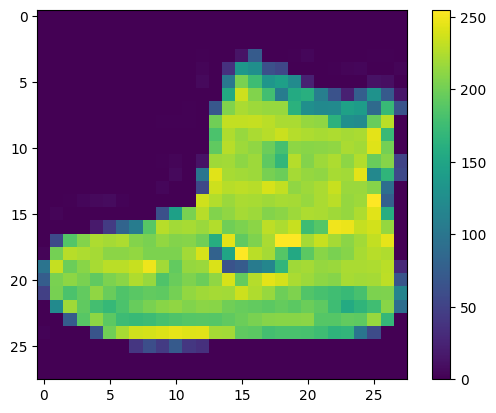

In [19]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [20]:
train_images = train_images / 255.0
test_images = test_images / 255.0

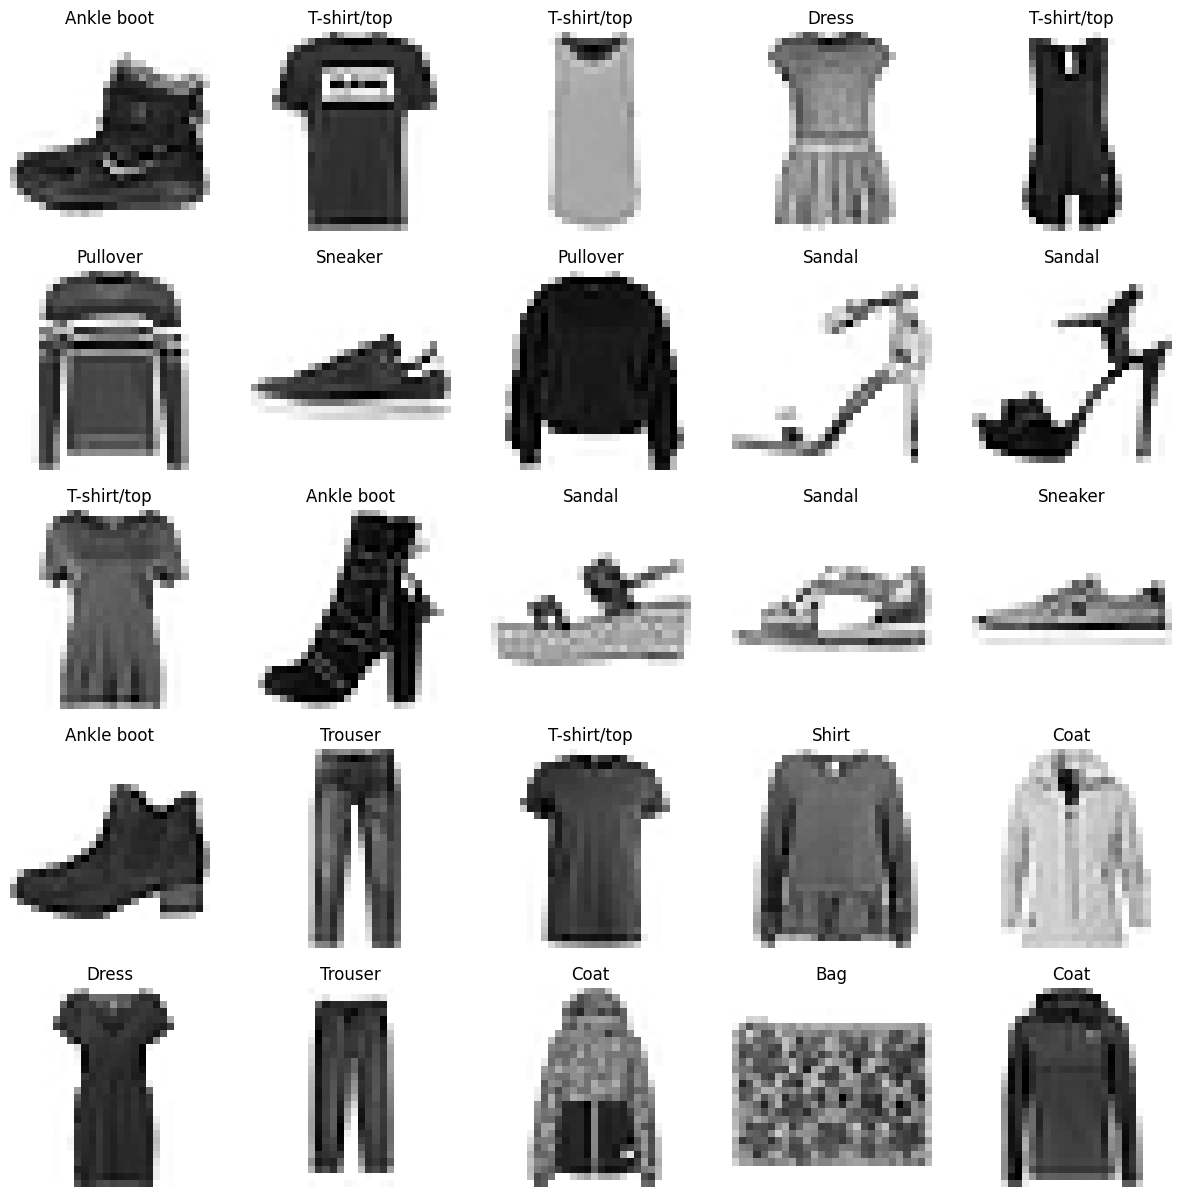

In [21]:
fig, axs = plt.subplots(5, 5, figsize = (15, 15))

for i in range(25):
    axs[i//5, i%5].imshow(train_images[i], cmap = plt.cm.binary)
    axs[i//5, i%5].axis('off')
    axs[i//5, i%5].set_title(class_names[train_labels[i]])

plt.show()

### Build the model

In [22]:
# architecture of the model
model = tf.keras.Sequential([
    
    tf.keras.layers.Flatten(input_shape = (28, 28)),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(10)

])

In [23]:
model.compile(  optimizer = 'adam',
                loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
                metrics=['accuracy']  )

### Train the model

In [24]:
model.fit(train_images, train_labels, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 777us/step - accuracy: 0.7792 - loss: 0.6254
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - accuracy: 0.8621 - loss: 0.3789
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.8765 - loss: 0.3408
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.8839 - loss: 0.3132
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.8901 - loss: 0.2924
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.8986 - loss: 0.2746
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - accuracy: 0.9023 - loss: 0.2640
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step - accuracy: 0.9051 - loss: 0.2569
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step - accuracy: 0.9085 - loss: 0.2421
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step - accuracy: 0.9082 - loss: 0.2416


### Evaluate accuracy

In [25]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose = 2)

print('\nTest accuracy:', test_acc)

313/313 - 0s - 659us/step - accuracy: 0.8825 - loss: 0.3421

Test accuracy: 0.8824999928474426


### Make predictions

In [26]:
probability_model = tf.keras.Sequential([   model, 
                                            tf.keras.layers.Softmax()   ])
predictions = probability_model.predict(test_images)

print(f"Predictions: {predictions[0]}")
print(f"Maximal probability: {np.argmax(predictions[0])}")
print(f"Actual label: {test_labels[0]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
Predictions: [2.0148288e-08 4.0639063e-12 1.0801220e-07 2.7332972e-10 1.2927454e-09
 3.2939850e-03 2.6556304e-08 3.5842512e-02 3.8366306e-08 9.6086335e-01]
Maximal probability: 9
Actual label: 9


In [27]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap = plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color = color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color = "#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')


### Verify predictions

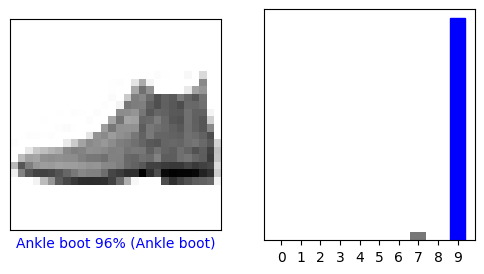

In [28]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

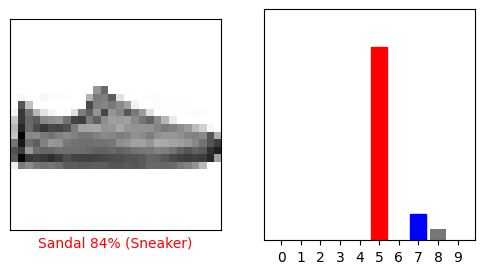

In [29]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()


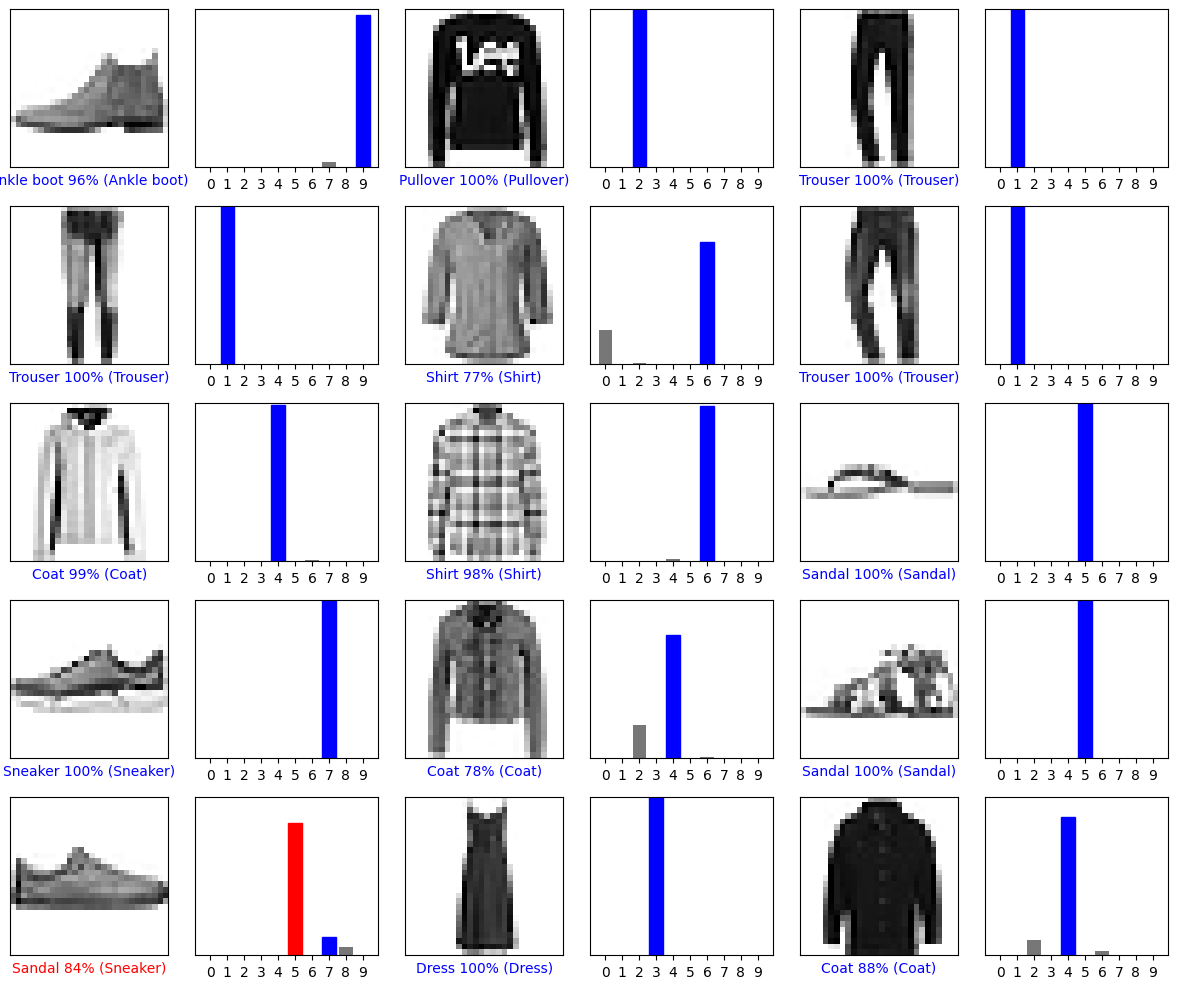

In [30]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()


### Use the trained model

In [31]:
# Grab an image from the test dataset.
img = test_images[1]
print(img.shape)

(28, 28)


In [32]:
# Add the image to a batch where it's the only member.
img = (np.expand_dims(img, 0))
print(img.shape)

(1, 28, 28)


In [33]:
predictions_single = probability_model.predict(img)
print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[2.6000267e-05 3.5700365e-14 9.9729508e-01 7.8467600e-11 1.8953872e-03
  4.1276207e-16 7.8358199e-04 1.0900056e-20 5.2680325e-12 2.3759255e-15]]


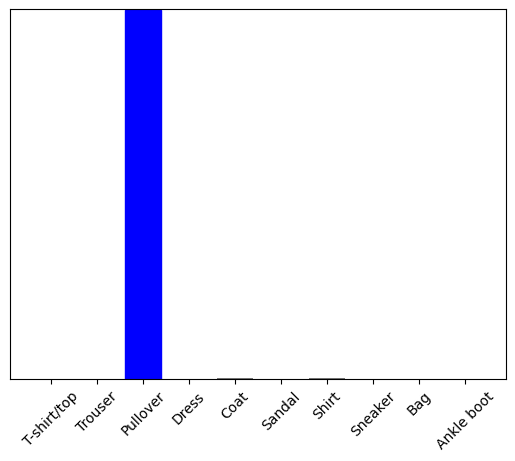

In [34]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation = 45)
plt.show()

In [35]:
np.argmax(predictions_single[0])

2

#### Saving and Viewing Model

In [36]:
create_dir('fashion_prediction')
create_dir('fashion_probability')

In [37]:
# Saving the model
model.save('fashion_prediction/model.keras')
probability_model.save('fashion_probability/probability_model.keras')

In [38]:
# Loading the model
fashion_prediction = tf.keras.models.load_model('fashion_prediction/model.keras')
fashion_probability = tf.keras.models.load_model('fashion_probability/probability_model.keras')

In [39]:
# Viewing the model
print(fashion_prediction.summary())
print(fashion_probability.summary()) 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (32, 10)               │       101,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (32, 10)               │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None
